<a href="https://colab.research.google.com/github/fadelhandiyono/Praktikum-Deret-Waktu-2026/blob/main/Tugas%20Praktikum_Minggu_3_Model_Stasioner.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TUGAS KELOMPOK — Model Stasioner (MA & AR)
**STA2542 — Analisis Deret Waktu**

Seed kelompok yang digunakan (jumlah 2 digit terakhir NIM seluruh anggota kelompok): **`137`**
`np.random.seed(137)` dipanggil ulang di setiap simulasi baru agar seluruh hasil pada notebook
ini reproducible.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

import warnings
warnings.filterwarnings("ignore")

## Soal 1
Buatlah simulasi deret MA(1) dengan panjang pengamatan 20 dengan nilai parameter
$\theta = 0.1,\ 0.3,\ 0.7,\ 1.0,\ 1.5,\ 2.0$.

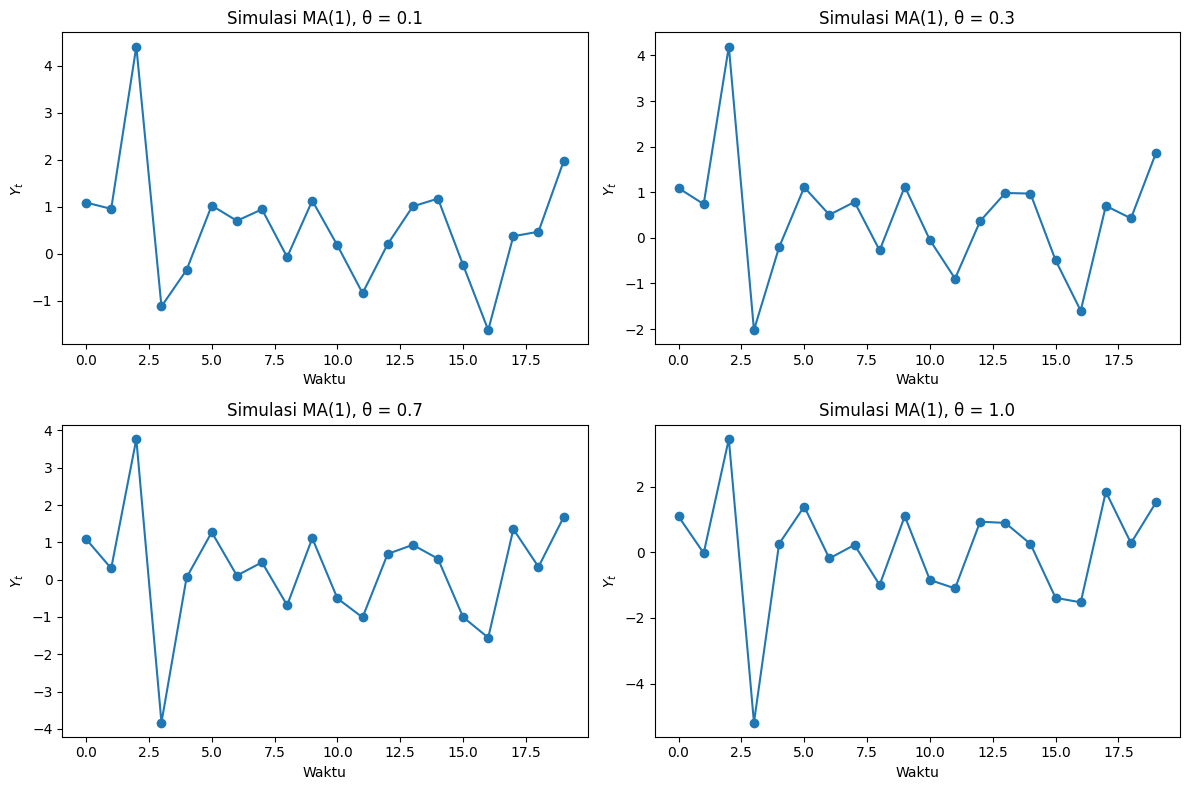

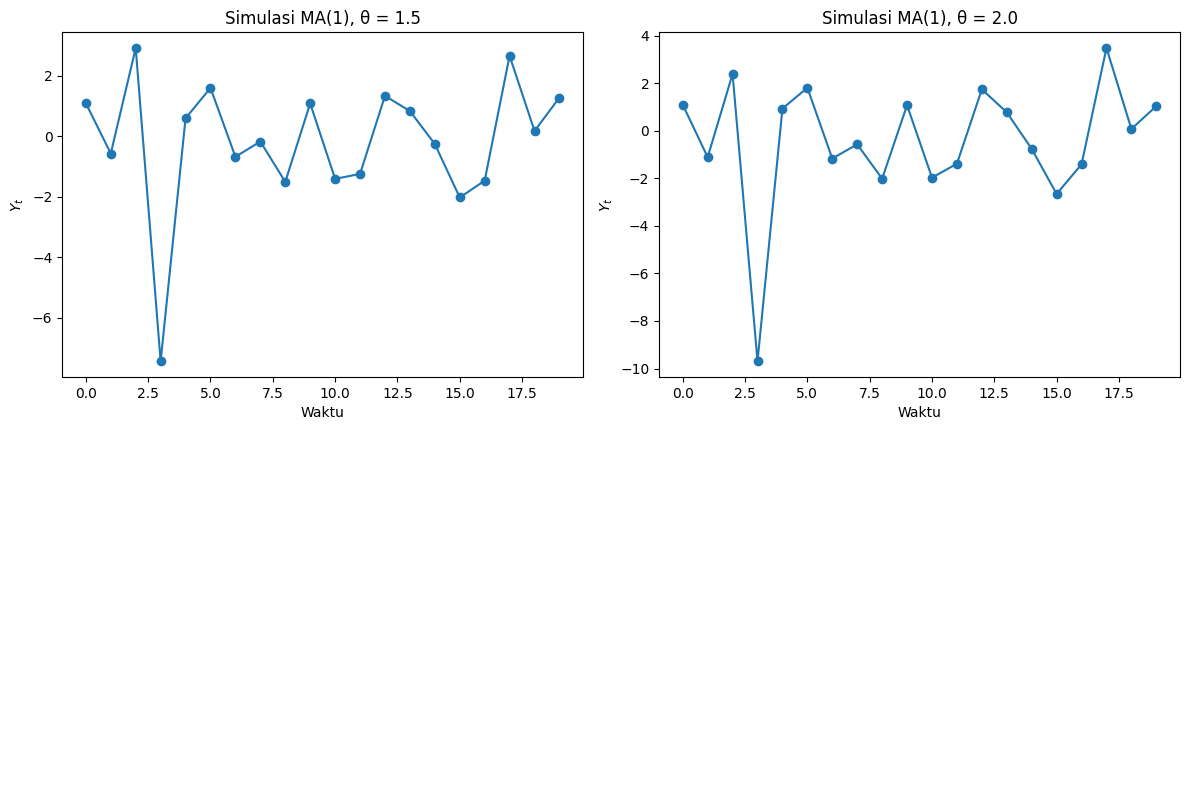

In [ ]:
# Nomor 1
# Simulasi deret MA(1) dengan panjang pengamatan 20

theta_values = [0.1, 0.3, 0.7, 1.0, 1.5, 2.0]
n = 20

hasil_ma1_theta = {}

for theta in theta_values:

    # seed kelompok
    np.random.seed(137)

    # Parameter model MA(1)
    ar_params = np.array([1])
    ma_params = np.array([1, -theta])

    # Membentuk proses MA(1)
    ma_object = ArmaProcess(ar_params, ma_params)

    # Simulasi data
    data_ma1 = ma_object.generate_sample(nsample=n)

    # Menyimpan hasil simulasi
    hasil_ma1_theta[theta] = data_ma1

    # Plot deret waktu
for start in range(0, len(theta_values), 4):
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    axes = axes.flatten()

    subset_theta = theta_values[start:start+4]

    for i, theta in enumerate(subset_theta):
        axes[i].plot(hasil_ma1_theta[theta], '-o')
        axes[i].set_title(f'Simulasi MA(1), θ = {theta}')
        axes[i].set_xlabel('Waktu')
        axes[i].set_ylabel(r'$Y_t$')

    for j in range(len(subset_theta), 4):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

## Soal 2
Buatlah plot ACF dari masing-masing deret hasil simulasi pada nomor 1 dan bandingkan.
Berdasarkan plot ACF tersebut, apa yang dapat Anda simpulkan terkait nilai autokorelasi
pada lag 1 pada model MA(1)?

*(Hint: identifikasi pola nilai autokorelasi berdasarkan nilai parameter MA, kaitkan
nilai autokorelasi sampel dengan nilai autokorelasi MA(1) secara teori.)*

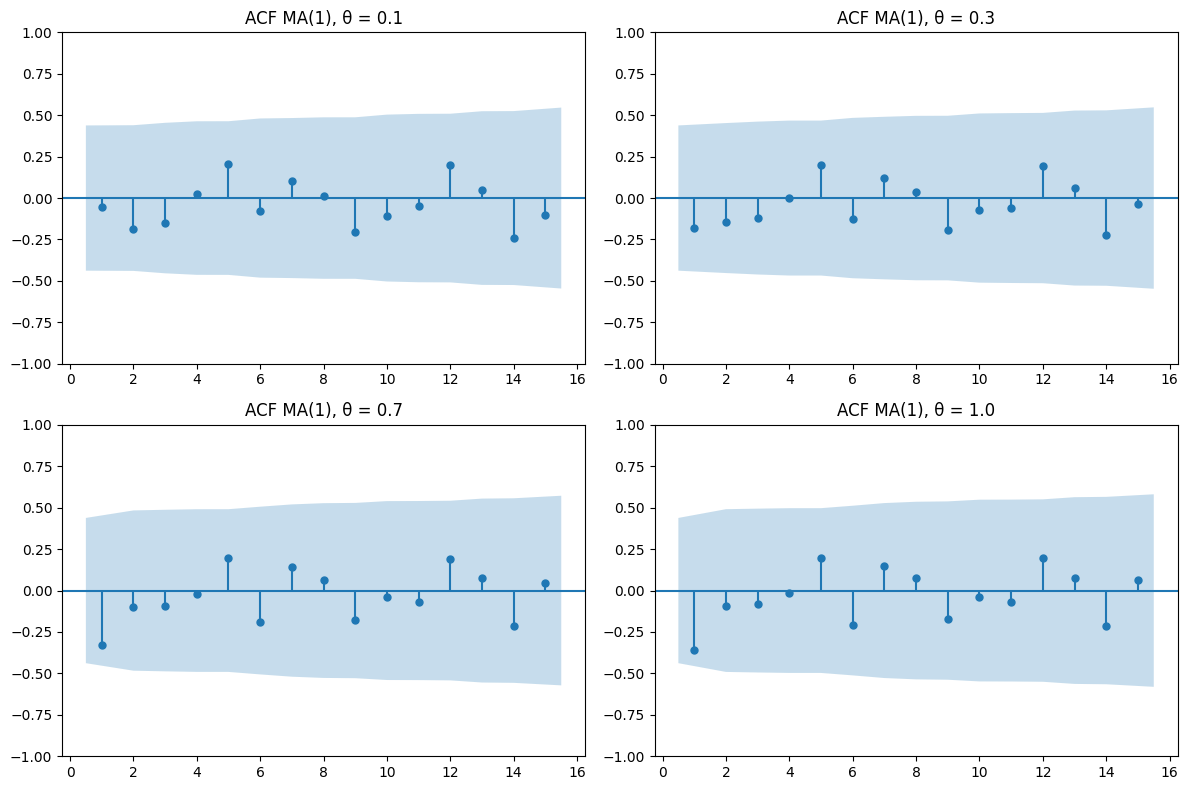

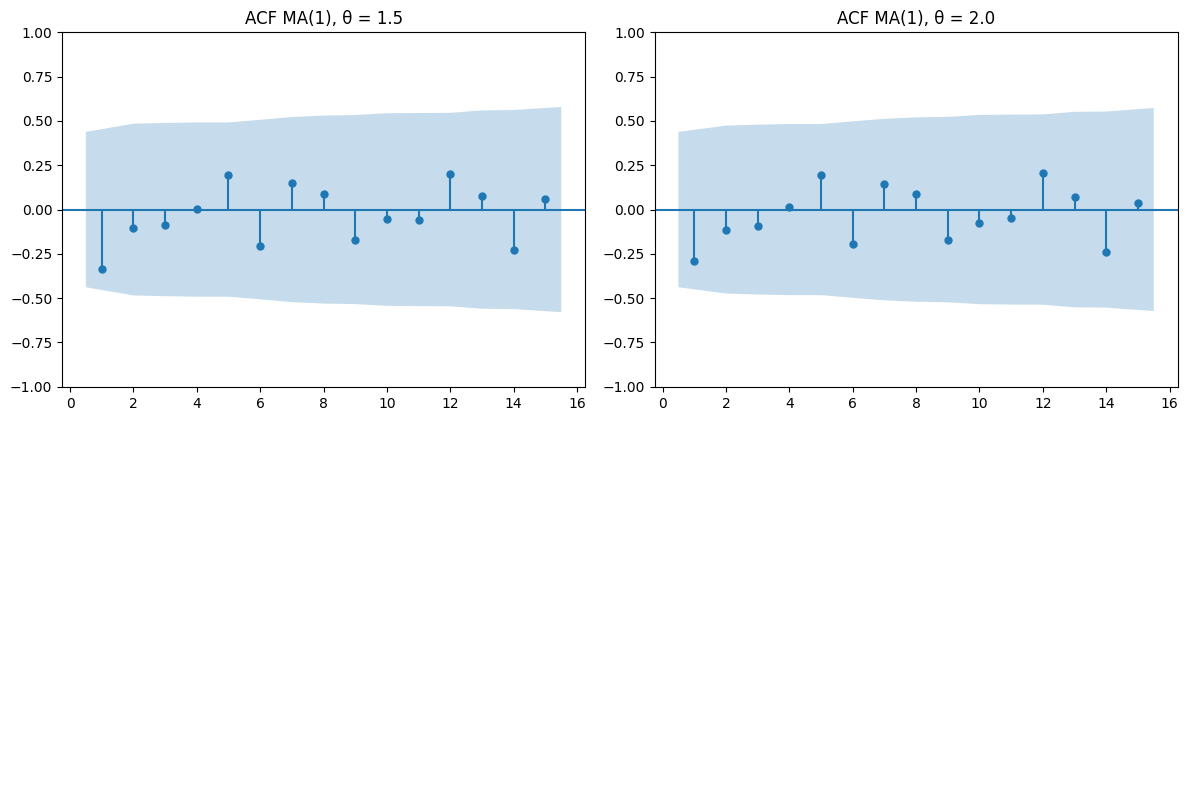

  theta |   rho1 teori |  rho1 sampel
   0.10 |      -0.0990 |      -0.0575
   0.30 |      -0.2752 |      -0.1906
   0.70 |      -0.4698 |      -0.3423
   1.00 |      -0.5000 |      -0.3685
   1.50 |      -0.4615 |      -0.3420
   2.00 |      -0.4000 |      -0.2961


In [ ]:
# Nomor 2
# Plot ACF dari masing-masing deret hasil simulasi pada nomor 1

for start in range(0, len(theta_values), 4):
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    axes = axes.flatten()

    subset_theta = theta_values[start:start+4]

    for i, theta in enumerate(subset_theta):
        plot_acf(hasil_ma1_theta[theta], zero=False, lags=15, ax=axes[i])
        axes[i].set_title(f'ACF MA(1), θ = {theta}')

    for j in range(len(subset_theta), 4):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

# Bandingkan rho1 teori dengan autokorelasi sampel pada lag 1
print(f"{'theta':>7} | {'rho1 teori':>12} | {'rho1 sampel':>12}")
for theta in theta_values:
    rho1_teori = -theta / (1 + theta**2)
    rho1_sampel = pd.Series(hasil_ma1_theta[theta]).autocorr(lag=1)
    print(f"{theta:7.2f} | {rho1_teori:12.4f} | {rho1_sampel:12.4f}")

**Jawaban / interpretasi nomor 2:**

- Secara teori, untuk MA(1) berlaku $\rho_1=\dfrac{-\theta}{1+\theta^2}$ dan $\rho_k=0$ untuk $k\ge2$.
  Nilai ini **selalu negatif untuk $\theta>0$**, dan besarnya (magnitude) mencapai **maksimum
  $|\rho_1|=0.5$ tepat pada $\theta=1$**, kemudian menurun kembali baik untuk $\theta<1$ maupun $\theta>1$
  (fungsi $f(\theta)=-\theta/(1+\theta^2)$ bersifat simetris terhadap transformasi $\theta \to 1/\theta$:
  nilai $\rho_1$ untuk $\theta$ dan $1/\theta$ selalu identik — inilah alasan teoretis mengapa syarat
  keterbalikan/invertibilitas MA(1) membutuhkan $|\theta|<1$, karena tanpa syarat ini dua nilai
  $\theta$ yang berbeda ($\theta$ dan $1/\theta$) menghasilkan ACF yang persis sama / tidak dapat
  dibedakan).
- Pada plot ACF contoh, di semua nilai $\theta$ terlihat **hanya lag 1 yang keluar dari selang
  kepercayaan $0\pm 2/\sqrt n$** (lag 2 dan seterusnya berada dalam selang / tidak signifikan) —
  ini merupakan ciri khas MA(1): ACF *cut-off* setelah lag 1.
- Nilai autokorelasi sampel pada lag 1 ($r_1$) mendekati arah dan pola nilai teoretis $\rho_1$
  meskipun tidak identik, karena $n=20$ relatif kecil sehingga galat pendugaan (sampling error)
  cukup besar.
- Untuk $\theta=1.0,\,1.5,\,2.0$ (yaitu $|\theta|\ge1$, kondisi **tidak invertible**), proses tetap
  **stasioner** (MA selalu stasioner untuk sembarang $\theta$) sehingga tetap bisa disimulasikan dan
  memiliki ACF dengan bentuk cut-off yang sama; hanya saja proses ini **tidak dapat dinyatakan
  kembali sebagai proses AR berorde tak-hingga** — ini menegaskan bahwa kestasioneran dan
  invertibilitas adalah dua sifat yang berbeda.

## Soal 3
Buatlah simulasi deret MA(1) dengan parameter $\theta=0.25$ dengan panjang pengamatan
$n = 60,\ 100,\ 150,\ 300$.

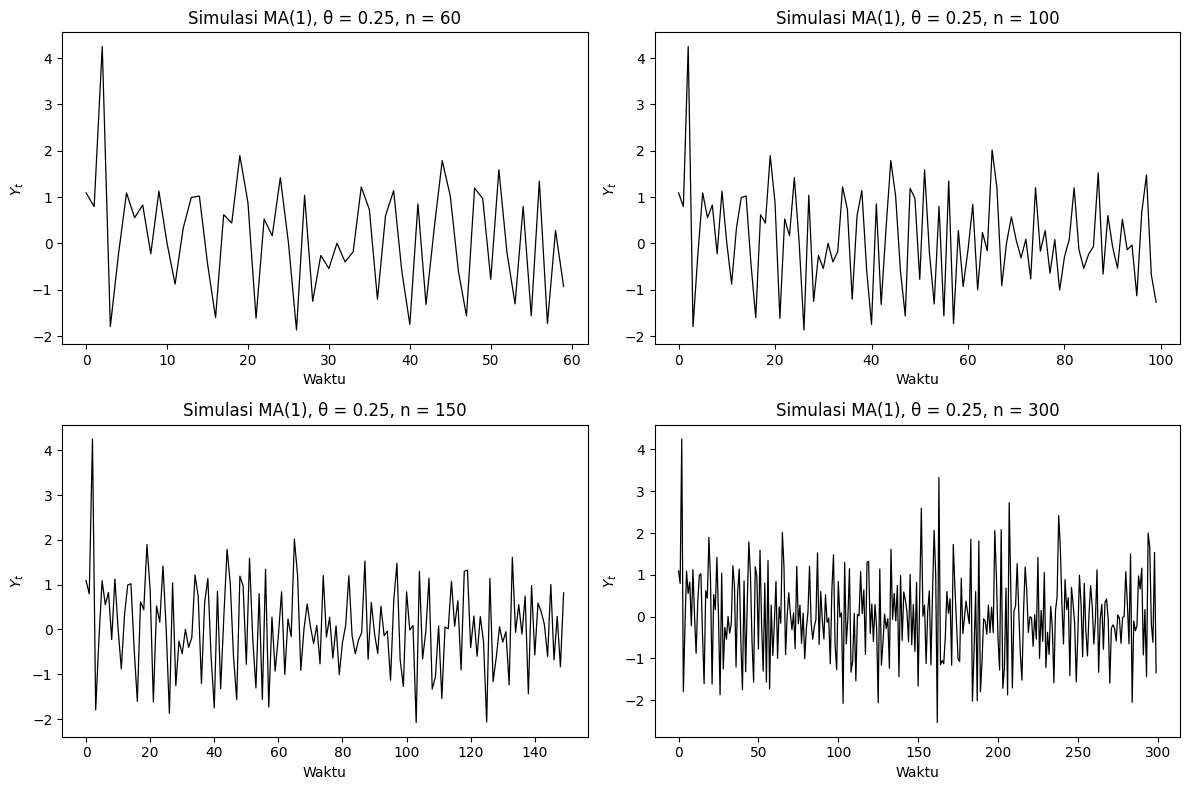

In [ ]:
# Nomor 3
# Simulasi deret MA(1) dengan theta = 0.25 untuk beberapa panjang pengamatan

theta_3 = 0.25
n_values = [60, 100, 150, 300]

hasil_ma1_n = {}

for n_obs in n_values:

    # seed kelompok
    np.random.seed(137)

    # Parameter model MA(1)
    ar_params = np.array([1])
    ma_params = np.array([1, -theta_3])

    # Membentuk proses MA(1)
    ma_object = ArmaProcess(ar_params, ma_params)

    # Simulasi data
    data_ma1_n = ma_object.generate_sample(nsample=n_obs)

    # Menyimpan hasil simulasi
    hasil_ma1_n[n_obs] = data_ma1_n

    # Plot deret waktu
for start in range(0, len(n_values), 4):
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    axes = axes.flatten()

    subset_n = n_values[start:start+4]

    for i, n_obs in enumerate(subset_n):
        axes[i].plot(hasil_ma1_n[n_obs], '-k', linewidth=0.9)
        axes[i].set_title(f'Simulasi MA(1), θ = {theta_3}, n = {n_obs}')
        axes[i].set_xlabel('Waktu')
        axes[i].set_ylabel(r'$Y_t$')

    for j in range(len(subset_n), 4):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

## Soal 4
Buatlah plot ACF dari masing-masing deret hasil simulasi pada nomor 3 dan bandingkan.
Berdasarkan plot ACF tersebut apa yang dapat Anda simpulkan terkait nilai autokorelasi
pada lag 1 pada model MA(1)?

*(Hint: identifikasi pola interval kepercayaan dari nilai autokorelasi berdasarkan panjang observasi.)*

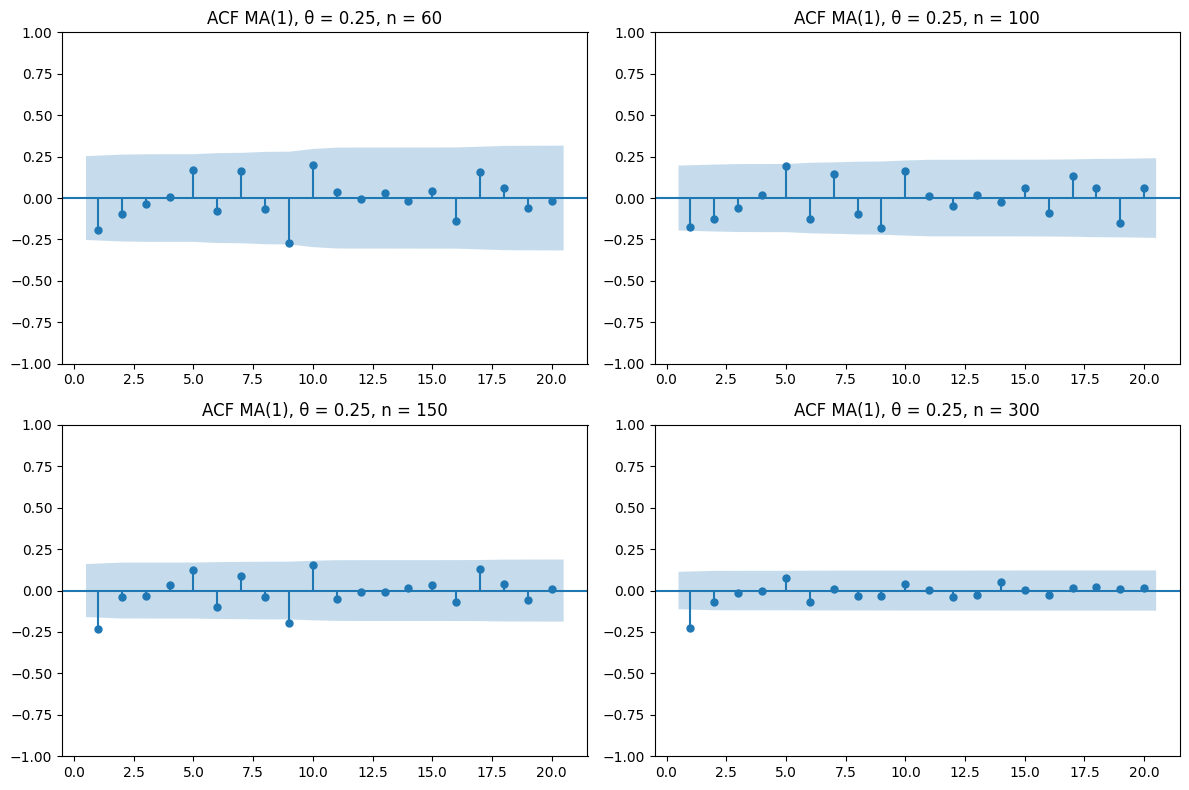

rho1 teori = -0.2353
    n |  r1 sampel | lebar selang 2/sqrt(n)
   60 |    -0.1937 |                 0.2582
  100 |    -0.1778 |                 0.2000
  150 |    -0.2363 |                 0.1633
  300 |    -0.2257 |                 0.1155


In [ ]:
# Nomor 4
# Plot ACF dari masing-masing deret hasil simulasi pada nomor 3

for start in range(0, len(n_values), 4):
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    axes = axes.flatten()

    subset_n = n_values[start:start+4]

    for i, n_obs in enumerate(subset_n):
        plot_acf(hasil_ma1_n[n_obs], zero=False, lags=20, ax=axes[i])
        axes[i].set_title(f'ACF MA(1), θ = {theta_3}, n = {n_obs}')

    for j in range(len(subset_n), 4):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

rho1_teori_3 = -theta_3 / (1 + theta_3**2)
print("rho1 teori =", round(rho1_teori_3, 4))
print(f"{'n':>5} | {'r1 sampel':>10} | {'lebar selang 2/sqrt(n)':>22}")
for n_obs in n_values:
    r1 = pd.Series(hasil_ma1_n[n_obs]).autocorr(lag=1)
    print(f"{n_obs:5d} | {r1:10.4f} | {2/np.sqrt(n_obs):22.4f}")

**Jawaban / interpretasi nomor 4:**

- Nilai teoretis $\rho_1=-\theta/(1+\theta^2)$ **tidak berubah** terhadap panjang pengamatan $n$ —
  ia murni fungsi dari parameter $\theta$. Yang berubah seiring bertambahnya $n$ adalah **presisi
  pendugaannya**.
- Selang kepercayaan (galat baku) autokorelasi contoh, $0\pm 2/\sqrt n$, **semakin menyempit** ketika
  $n$ membesar ($n=60\to$ selang lebar $\approx\pm0.258$; $n=300\to$ selang lebar $\approx\pm0.115$).
  Ini terlihat pada plot ACF: pita biru (confidence band) semakin sempit untuk $n$ yang lebih besar.
- Karena $\theta=0.25$ menghasilkan $\rho_1\approx-0.235$ (di bawah $0.258$ untuk $n=60$), pada
  $n=60$ nilai $r_1$ contoh **kadang tidak signifikan berbeda dari nol** (berada di dalam pita),
  sedangkan pada $n$ yang lebih besar (150, 300) nilai $r_1$ jauh lebih konsisten keluar dari selang
  dan mendekati nilai teoretisnya.
- Simpulan umum: **makin panjang deret pengamatan, makin teliti (presisi) pendugaan autokorelasi**,
  dan makin mudah kita membedakan autokorelasi yang benar-benar ada dari autokorelasi akibat
  kebetulan sampling semata.

## Soal 5
Buatlah simulasi deret MA(2) dengan panjang pengamatan 50 dengan parameter:

a. $\theta_1=0.3,\ \theta_2=0.8$
b. $\theta_1=-0.3,\ \theta_2=0.8$
c. $\theta_1=0.3,\ \theta_2=-0.8$
d. $\theta_1=-0.3,\ \theta_2=-0.8$

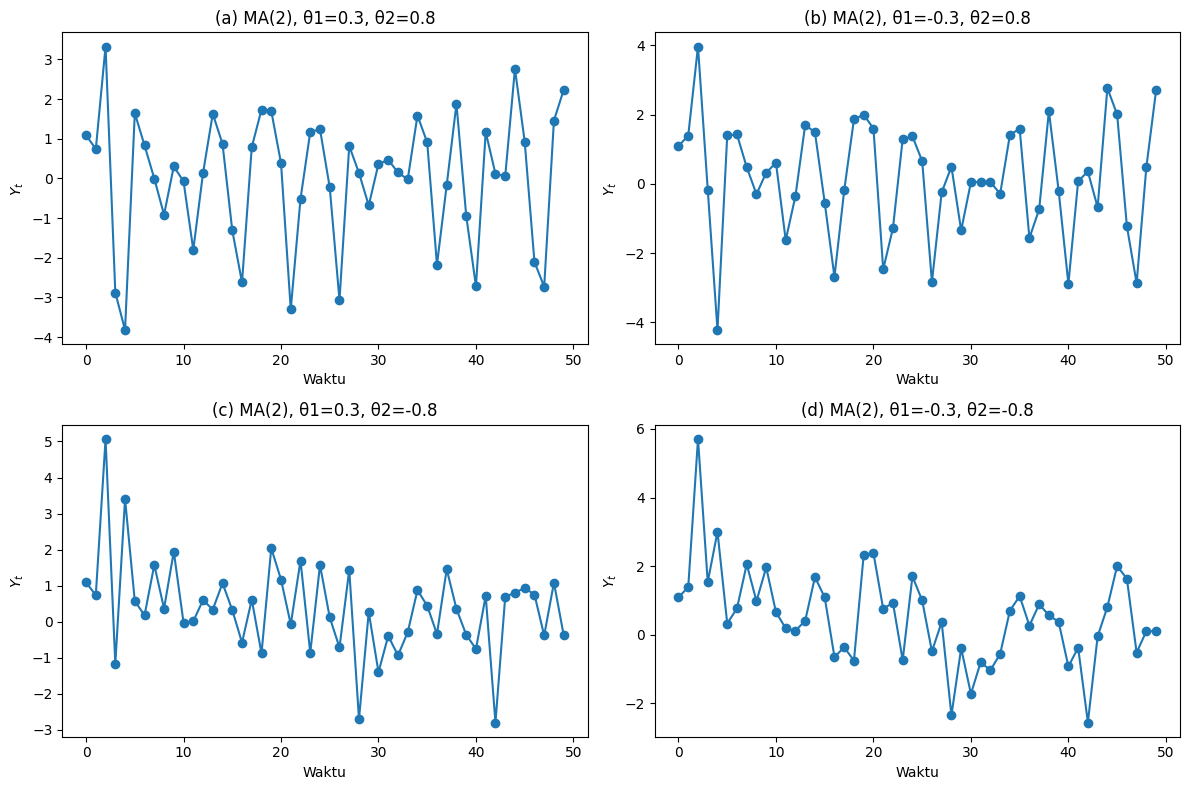

In [ ]:
# Nomor 5
# Simulasi deret MA(2) dengan panjang pengamatan 50

n5 = 50
kasus_ma2 = {
    'a': (0.3, 0.8),
    'b': (-0.3, 0.8),
    'c': (0.3, -0.8),
    'd': (-0.3, -0.8),
}
label_ma2 = list(kasus_ma2.keys())

hasil_ma2 = {}

for label in label_ma2:
    theta1, theta2 = kasus_ma2[label]

    # seed kelompok
    np.random.seed(137)

    # Parameter model MA(2)
    ar_params = np.array([1])
    ma_params = np.array([1, -theta1, -theta2])

    # Membentuk proses MA(2)
    ma_object = ArmaProcess(ar_params, ma_params)

    # Simulasi data
    data_ma2 = ma_object.generate_sample(nsample=n5)

    # Menyimpan hasil simulasi
    hasil_ma2[label] = data_ma2

    # Plot deret waktu
for start in range(0, len(label_ma2), 4):
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    axes = axes.flatten()

    subset_label = label_ma2[start:start+4]

    for i, label in enumerate(subset_label):
        theta1, theta2 = kasus_ma2[label]
        axes[i].plot(hasil_ma2[label], '-o')
        axes[i].set_title(f'({label}) MA(2), θ1={theta1}, θ2={theta2}')
        axes[i].set_xlabel('Waktu')
        axes[i].set_ylabel(r'$Y_t$')

    for j in range(len(subset_label), 4):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

## Soal 6
Buatlah plot ACF dari masing-masing deret hasil simulasi pada nomor 5 dan bandingkan.
Berdasarkan plot ACF tersebut apa yang dapat Anda simpulkan terkait nilai autokorelasi
pada lag 1 dan 2 dari deret MA(2)?

*(Hint: identifikasi pola nilai autokorelasi berdasarkan nilai parameter MA.)*

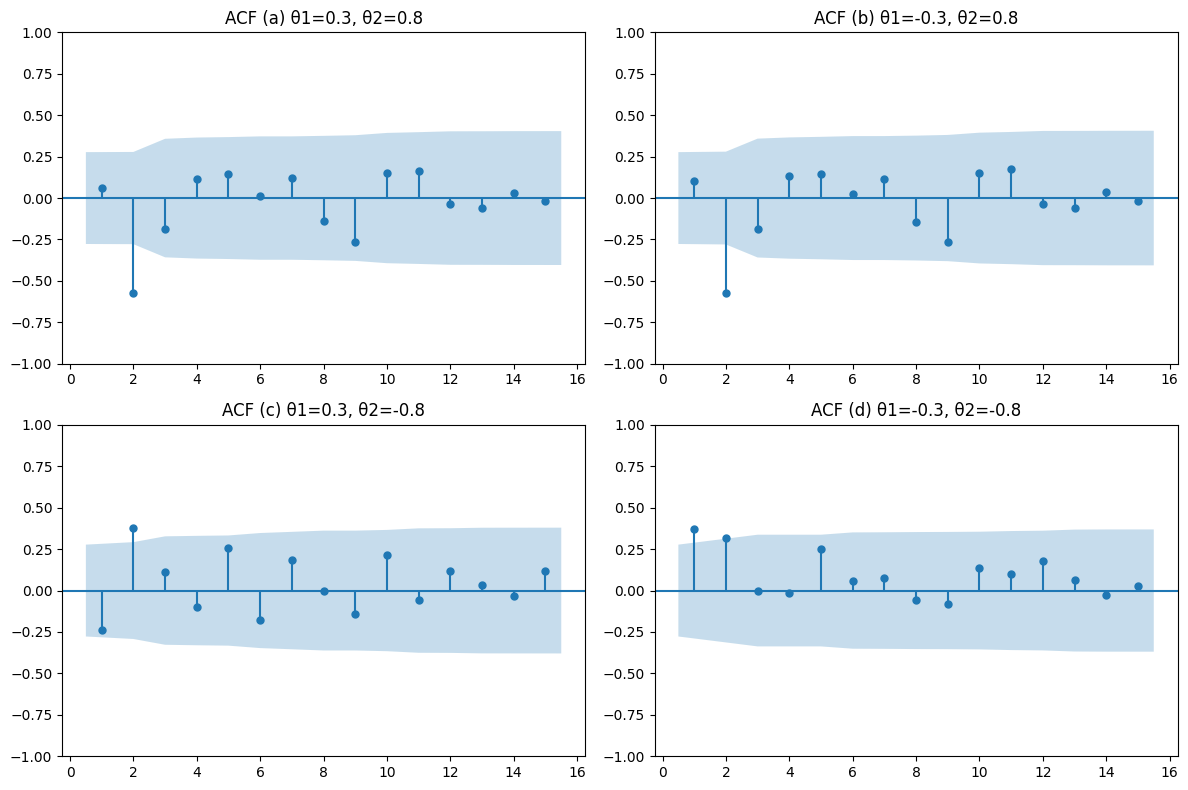

kasus |  theta1 |  theta2 | rho1 teori | rho2 teori | r1 sampel | r2 sampel
    a |    0.30 |    0.80 |    -0.0347 |    -0.4624 |    0.0632 |   -0.5943
    b |   -0.30 |    0.80 |     0.0347 |    -0.4624 |    0.1033 |   -0.5926
    c |    0.30 |   -0.80 |    -0.3121 |     0.4624 |   -0.2377 |    0.3794
    d |   -0.30 |   -0.80 |     0.3121 |     0.4624 |    0.3720 |    0.3214


In [ ]:
# Nomor 6
# Plot ACF dari masing-masing deret hasil simulasi pada nomor 5

for start in range(0, len(label_ma2), 4):
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    axes = axes.flatten()

    subset_label = label_ma2[start:start+4]

    for i, label in enumerate(subset_label):
        theta1, theta2 = kasus_ma2[label]
        plot_acf(hasil_ma2[label], zero=False, lags=15, ax=axes[i])
        axes[i].set_title(f'ACF ({label}) θ1={theta1}, θ2={theta2}')

    for j in range(len(subset_label), 4):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

print(f"{'kasus':>5} | {'theta1':>7} | {'theta2':>7} | {'rho1 teori':>10} | {'rho2 teori':>10} | {'r1 sampel':>9} | {'r2 sampel':>9}")
for label in label_ma2:
    theta1, theta2 = kasus_ma2[label]
    denom = 1 + theta1**2 + theta2**2
    rho1_teori = (-theta1 + theta1*theta2) / denom
    rho2_teori = -theta2 / denom
    r1 = pd.Series(hasil_ma2[label]).autocorr(lag=1)
    r2 = pd.Series(hasil_ma2[label]).autocorr(lag=2)
    print(f"{label:>5} | {theta1:7.2f} | {theta2:7.2f} | {rho1_teori:10.4f} | {rho2_teori:10.4f} | {r1:9.4f} | {r2:9.4f}")

**Jawaban / interpretasi nomor 6:**

- Secara teori, untuk MA(2): $\rho_1=\dfrac{-\theta_1+\theta_1\theta_2}{1+\theta_1^2+\theta_2^2}$,
  $\rho_2=\dfrac{-\theta_2}{1+\theta_1^2+\theta_2^2}$, dan $\rho_k=0$ untuk $k\ge3$. Pada seluruh
  plot ACF terlihat **hanya lag 1 dan lag 2 yang signifikan (keluar dari selang $0\pm2/\sqrt n$)**,
  sedangkan lag $\ge3$ berada dalam selang — ini adalah ciri khas *cut-off* MA(2) setelah lag 2.
- **Tanda $\theta_2$ menentukan tanda $\rho_2$** (berbanding terbalik): $\theta_2=0.8$ (kasus a, b)
  menghasilkan $\rho_2$ negatif, sedangkan $\theta_2=-0.8$ (kasus c, d) menghasilkan $\rho_2$ positif.
- **Tanda $\theta_1$ ikut memengaruhi tanda dan besar $\rho_1$** melalui suku $-\theta_1+\theta_1\theta_2$:
  membalik tanda $\theta_1$ (dengan $\theta_2$ tetap) membalik tanda $\rho_1$ (bandingkan kasus a vs
  b, dan c vs d), sementara $|\rho_1|$ jauh lebih besar ketika $\theta_1$ dan $\theta_2$ "searah"
  secara efek pada rumus (kasus c, d dibanding a, b).
- Nilai autokorelasi sampel ($r_1, r_2$) berada di sekitar nilai teoretisnya, meskipun dengan $n=50$
  masih ada deviasi akibat galat sampling — konsisten dengan pola pada soal 2 dan 4.

## Soal 7
Buatlah simulasi deret AR(1) dengan 100 pengamatan dengan nilai parameter
$\phi = 0.3,\ 0.9,\ -0.3,\ -0.9$.

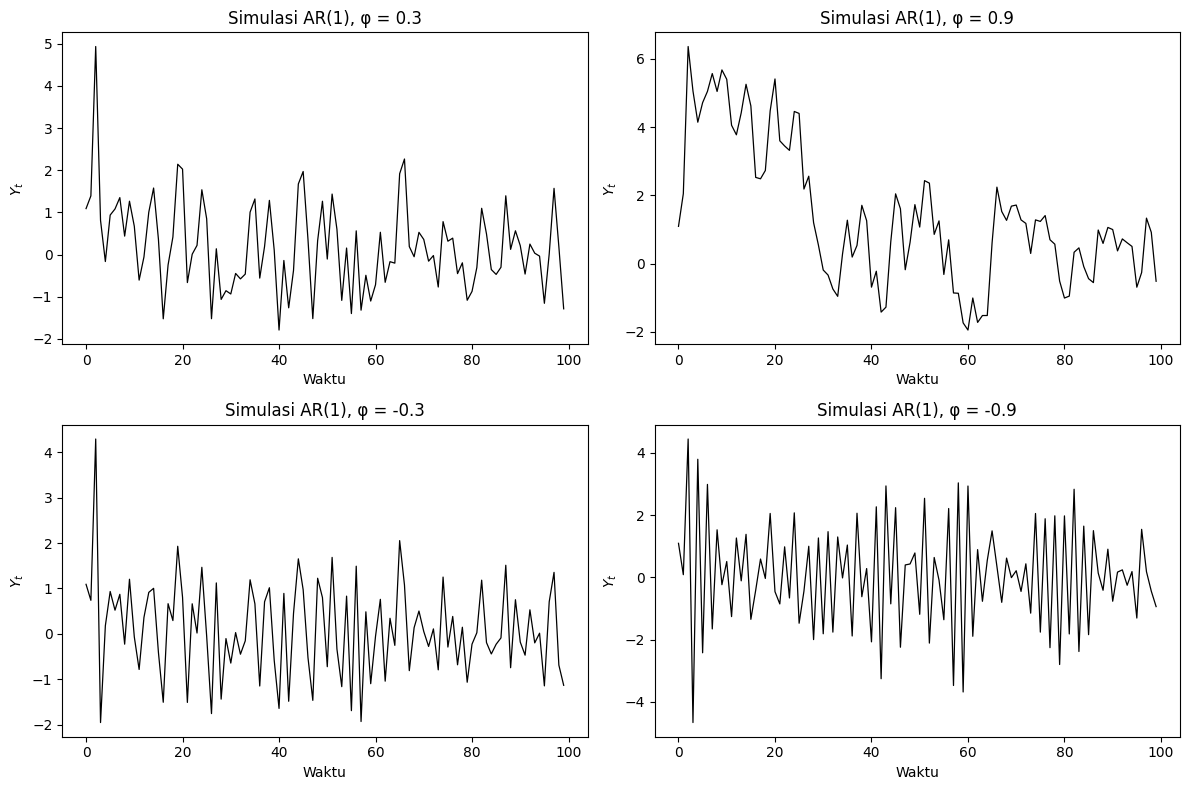

In [ ]:
# Nomor 7
# Simulasi deret AR(1) dengan panjang pengamatan 100

phi_values = [0.3, 0.9, -0.3, -0.9]
n7 = 100

hasil_ar1_phi = {}

for phi in phi_values:

    # seed kelompok
    np.random.seed(137)

    # Parameter model AR(1)
    ar_params = np.array([1, -phi])
    ma_params = np.array([1])

    # Membentuk proses AR(1)
    ar_object = ArmaProcess(ar_params, ma_params)

    # Simulasi data
    data_ar1 = ar_object.generate_sample(nsample=n7)

    # Menyimpan hasil simulasi
    hasil_ar1_phi[phi] = data_ar1

    # Plot deret waktu
for start in range(0, len(phi_values), 4):
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    axes = axes.flatten()

    subset_phi = phi_values[start:start+4]

    for i, phi in enumerate(subset_phi):
        axes[i].plot(hasil_ar1_phi[phi], '-k', linewidth=0.9)
        axes[i].set_title(f'Simulasi AR(1), φ = {phi}')
        axes[i].set_xlabel('Waktu')
        axes[i].set_ylabel(r'$Y_t$')

    for j in range(len(subset_phi), 4):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

## Soal 8
Buatlah plot ACF dan PACF dari masing-masing deret hasil simulasi pada nomor 7 dan bandingkan.
Berdasarkan plot ACF dan PACF tersebut apa yang dapat Anda simpulkan terkait nilai autokorelasi
pada deret AR(1)?

*(Hint: identifikasi pola nilai autokorelasi ataupun autokorelasi parsial berdasarkan nilai
parameter AR.)*

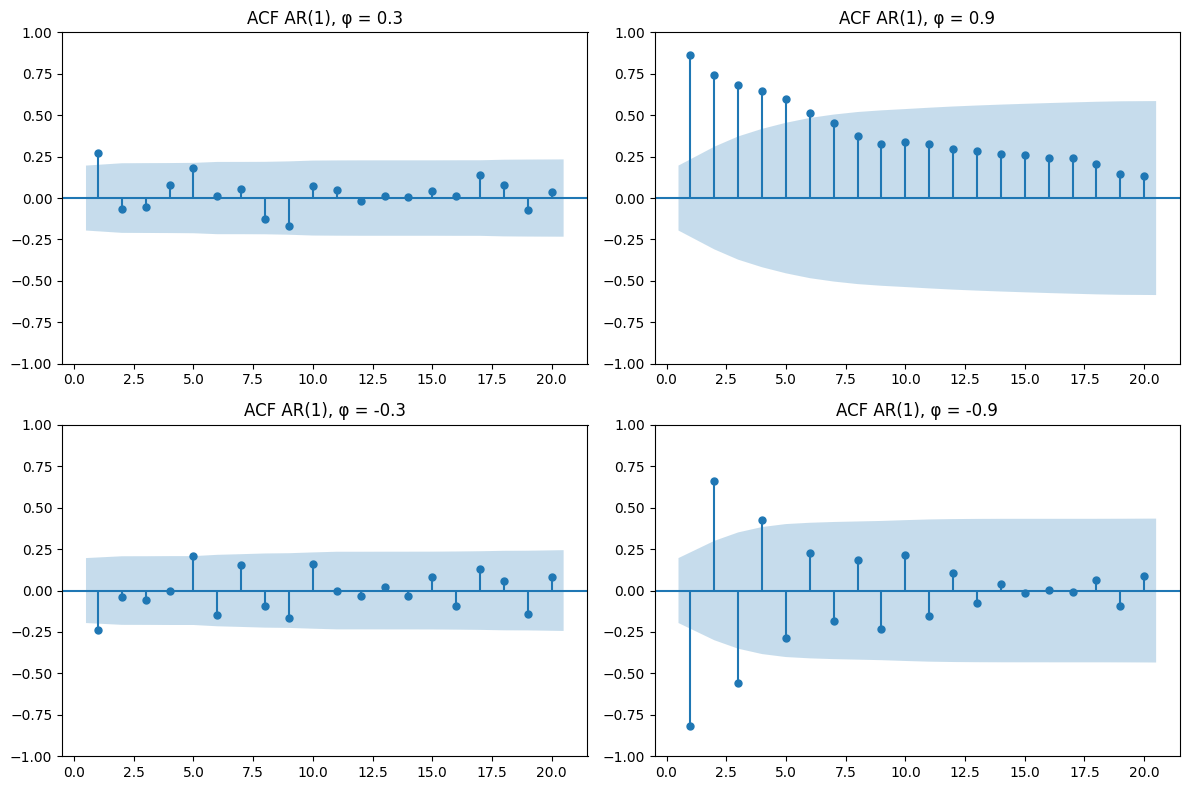

In [ ]:
# Nomor 8
# Plot ACF dari masing-masing deret hasil simulasi pada nomor 7

for start in range(0, len(phi_values), 4):
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    axes = axes.flatten()

    subset_phi = phi_values[start:start+4]

    for i, phi in enumerate(subset_phi):
        plot_acf(hasil_ar1_phi[phi], zero=False, lags=20, ax=axes[i])
        axes[i].set_title(f'ACF AR(1), φ = {phi}')

    for j in range(len(subset_phi), 4):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

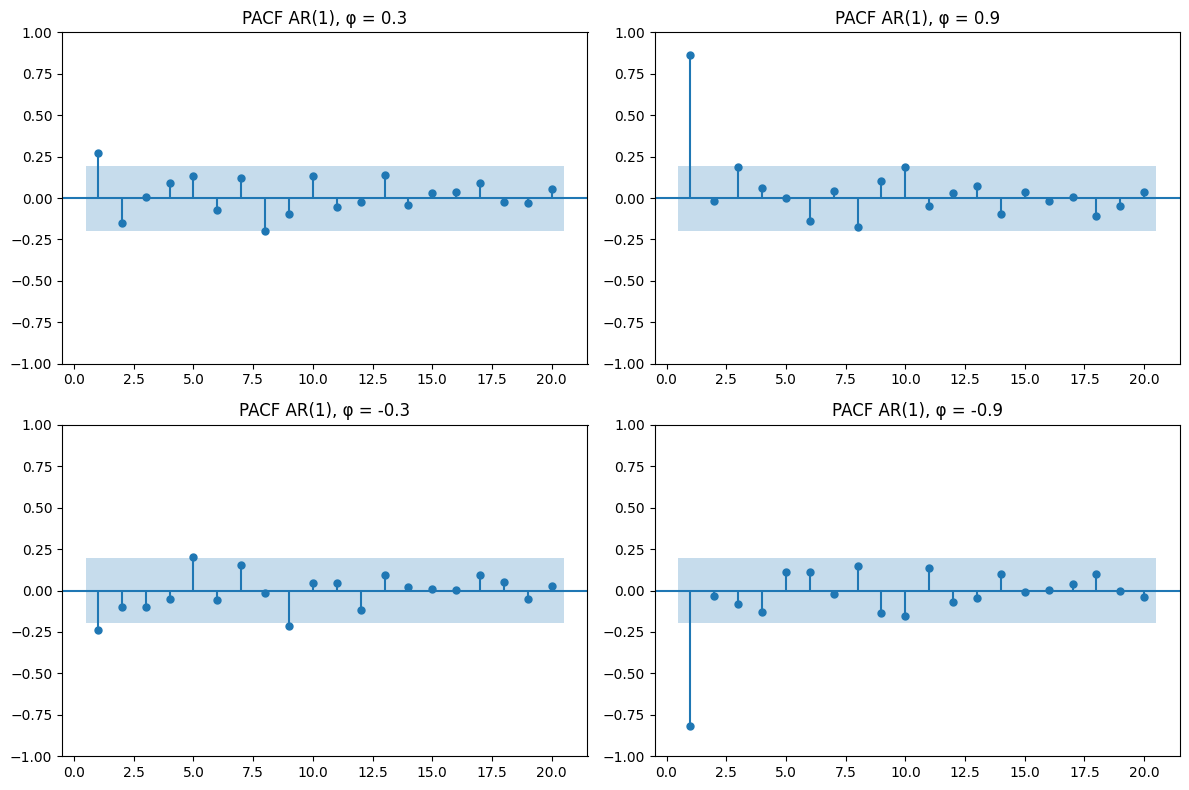

   phi | rho1 teori (=phi) | rho2 teori (=phi^2) | r1 sampel
  0.30 |            0.3000 |              0.0900 |    0.2760
  0.90 |            0.9000 |              0.8100 |    0.8688
 -0.30 |           -0.3000 |              0.0900 |   -0.2421
 -0.90 |           -0.9000 |              0.8100 |   -0.8205


In [ ]:
# Nomor 8 (lanjutan)
# Plot PACF dari masing-masing deret hasil simulasi pada nomor 7

for start in range(0, len(phi_values), 4):
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    axes = axes.flatten()

    subset_phi = phi_values[start:start+4]

    for i, phi in enumerate(subset_phi):
        plot_pacf(hasil_ar1_phi[phi], zero=False, lags=20, ax=axes[i])
        axes[i].set_title(f'PACF AR(1), φ = {phi}')

    for j in range(len(subset_phi), 4):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

print(f"{'phi':>6} | {'rho1 teori (=phi)':>17} | {'rho2 teori (=phi^2)':>19} | {'r1 sampel':>9}")
for phi in phi_values:
    r1 = pd.Series(hasil_ar1_phi[phi]).autocorr(lag=1)
    print(f"{phi:6.2f} | {phi:17.4f} | {phi**2:19.4f} | {r1:9.4f}")

**Jawaban / interpretasi nomor 8:**

- Secara teori $\rho_k=\phi^k$ untuk AR(1), sehingga **ACF menurun secara eksponensial** seiring $k$
  membesar. Pada $\phi>0$ (0.3 dan 0.9) semua $\rho_k$ **bertanda positif**; pada $\phi<0$ (−0.3 dan
  −0.9) tanda $\rho_k$ **berselang-seling (+/−)** karena $(-0.3)^k$ dan $(-0.9)^k$ bergantian tanda.
- Semakin besar $|\phi|$ (0.9 / −0.9 dibanding 0.3 / −0.3), semakin **lambat** peluruhan ACF-nya —
  autokorelasi tetap signifikan hingga lag yang lebih jauh, sesuai dengan deret yang tampak lebih
  "mulus"/persisten pada plot deret waktunya (soal 7).
- **PACF menunjukkan pola *cut-off* tegas setelah lag 1**: hanya lag 1 yang signifikan (nilainya
  $\approx\phi$), sedangkan lag $\ge2$ berada dalam selang kepercayaan (mendekati nol) — ini adalah
  ciri khas teoretis AR(1) dimana PACF$(k)=0$ untuk $k\ge2$.
- Kombinasi **ACF meluruh eksponensial (tidak cut-off) + PACF cut-off tegas di lag 1** inilah pola
  identifikasi baku untuk proses AR(1), berbeda dengan MA yang justru ACF-nya cut-off dan PACF-nya
  meluruh.

## Soal 9
Berdasarkan plot ACF dan PACF pada nomor 8, model apa yang disarankan untuk masing-masing deret?
Jelaskan jawaban Anda.

**Jawaban:**

Untuk **keempat** deret pada soal 7 & 8 ($\phi=0.3,\,0.9,\,-0.3,\,-0.9$), model yang disarankan
adalah **AR(1)**, karena pada seluruh kasus:

- Plot **ACF meluruh secara gradual / eksponensial** (tidak terpotong tajam pada lag tertentu, tapi
  terus mengecil), yang merupakan ciri proses AR, bukan MA (MA akan cut-off tajam).
- Plot **PACF terpotong (cut-off) tegas setelah lag 1** — hanya lag 1 yang signifikan secara
  statistik (keluar dari selang $0\pm2/\sqrt n$), lag-lag berikutnya tidak signifikan.
- Order PACF yang signifikan (=1) menunjukkan **ordo AR = 1**, sehingga model **AR(1)** paling sesuai
  untuk keempat deret tersebut — konsisten dengan proses pembangkitan datanya.
- Perbedaan antar-deret hanya pada **kecepatan peluruhan ACF** (lebih lambat untuk $|\phi|=0.9$) dan
  **pola tanda** (berselang-seling untuk $\phi$ negatif), bukan pada ordo model yang disarankan.

## Soal 10
Buatlah simulasi deret AR(2) dengan panjang pengamatan 100 dengan parameter:

a. $\phi_1=1.5,\ \phi_2=-0.5$
b. $\phi_1=0.75,\ \phi_2=-0.25$
c. $\phi_1=1,\ \phi_2=-0.25$
d. $\phi_1=0.5,\ \phi_2=-0.75$

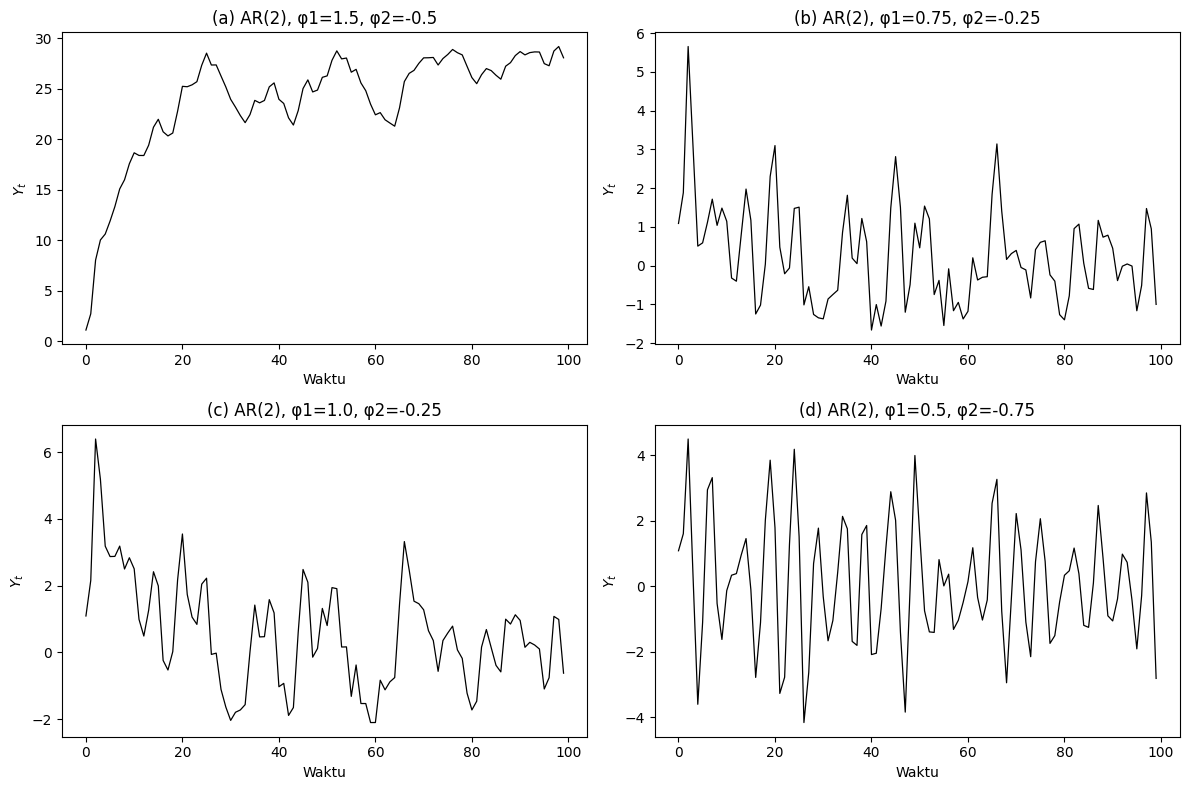

kasus |   phi1 |   phi2 |  phi1+phi2<1 |  phi2-phi1<1 |  |phi2|<1 | stasioner?
    a |   1.50 |  -0.50 |        False |         True |      True |      False
    b |   0.75 |  -0.25 |         True |         True |      True |       True
    c |   1.00 |  -0.25 |         True |         True |      True |       True
    d |   0.50 |  -0.75 |         True |         True |      True |       True


In [ ]:
# Nomor 10
# Simulasi deret AR(2) dengan panjang pengamatan 100

n10 = 100
kasus_ar2 = {
    'a': (1.5, -0.5),
    'b': (0.75, -0.25),
    'c': (1.0, -0.25),
    'd': (0.5, -0.75),
}
label_ar2 = list(kasus_ar2.keys())

hasil_ar2 = {}

for label in label_ar2:
    phi1, phi2 = kasus_ar2[label]

    # seed kelompok
    np.random.seed(137)

    # Parameter model AR(2)
    ar_params = np.array([1, -phi1, -phi2])
    ma_params = np.array([1])

    # Membentuk proses AR(2)
    ar_object = ArmaProcess(ar_params, ma_params)

    # Simulasi data
    data_ar2 = ar_object.generate_sample(nsample=n10)

    # Menyimpan hasil simulasi
    hasil_ar2[label] = data_ar2

    # Plot deret waktu
for start in range(0, len(label_ar2), 4):
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    axes = axes.flatten()

    subset_label = label_ar2[start:start+4]

    for i, label in enumerate(subset_label):
        phi1, phi2 = kasus_ar2[label]
        axes[i].plot(hasil_ar2[label], '-k', linewidth=0.9)
        axes[i].set_title(f'({label}) AR(2), φ1={phi1}, φ2={phi2}')
        axes[i].set_xlabel('Waktu')
        axes[i].set_ylabel(r'$Y_t$')

    for j in range(len(subset_label), 4):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

# Pemeriksaan syarat kestasioneran AR(2): phi1+phi2<1, phi2-phi1<1, |phi2|<1
print(f"{'kasus':>5} | {'phi1':>6} | {'phi2':>6} | {'phi1+phi2<1':>12} | {'phi2-phi1<1':>12} | {'|phi2|<1':>9} | {'stasioner?':>10}")
for label in label_ar2:
    phi1, phi2 = kasus_ar2[label]
    syarat1 = phi1 + phi2 < 1
    syarat2 = phi2 - phi1 < 1
    syarat3 = abs(phi2) < 1
    print(f"{label:>5} | {phi1:6.2f} | {phi2:6.2f} | {str(syarat1):>12} | {str(syarat2):>12} | {str(syarat3):>9} | {str(syarat1 and syarat2 and syarat3):>10}")

**Catatan kestasioneran (dari output kode di atas):**

Syarat stasioner AR(2) adalah $\phi_1+\phi_2<1$, $\phi_2-\phi_1<1$, dan $|\phi_2|<1$ (ketiganya harus
terpenuhi). Kasus **(a)** $\phi_1=1.5,\ \phi_2=-0.5$ memberikan $\phi_1+\phi_2=1.0$, **tepat di batas
(tidak $<1$)** — deret ini berada pada **kondisi non-stasioner / akar unit**, sengaja disertakan
sebagai kasus pembanding. Kasus **(b), (c), (d)** memenuhi ketiga syarat sehingga **stasioner**.

## Soal 11
Buatlah plot ACF dan PACF dari masing-masing deret hasil simulasi pada nomor 10. Berdasarkan plot
ACF dan PACF tersebut apa yang dapat Anda simpulkan terkait nilai autokorelasi ataupun autokorelasi
parsial berdasarkan nilai parameter AR?

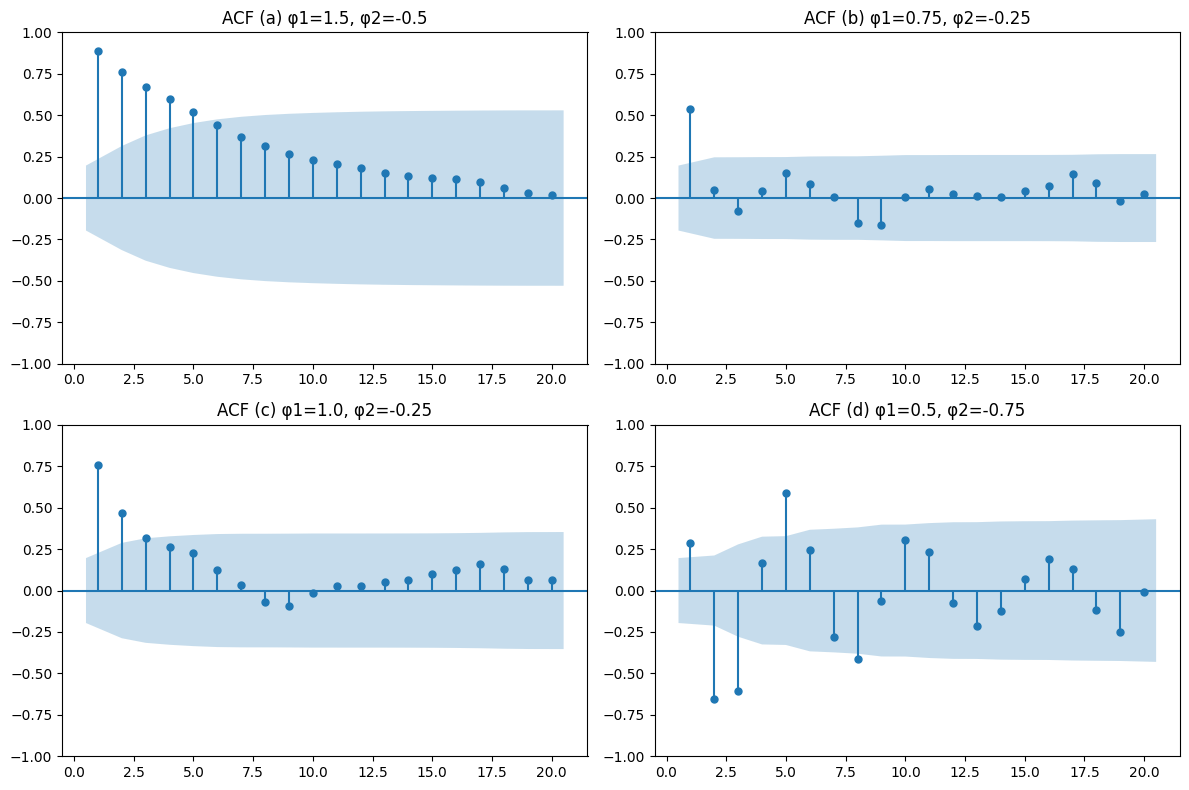

In [ ]:
# Nomor 11
# Plot ACF dari masing-masing deret hasil simulasi pada nomor 10

for start in range(0, len(label_ar2), 4):
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    axes = axes.flatten()

    subset_label = label_ar2[start:start+4]

    for i, label in enumerate(subset_label):
        phi1, phi2 = kasus_ar2[label]
        plot_acf(hasil_ar2[label], zero=False, lags=20, ax=axes[i])
        axes[i].set_title(f'ACF ({label}) φ1={phi1}, φ2={phi2}')

    for j in range(len(subset_label), 4):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

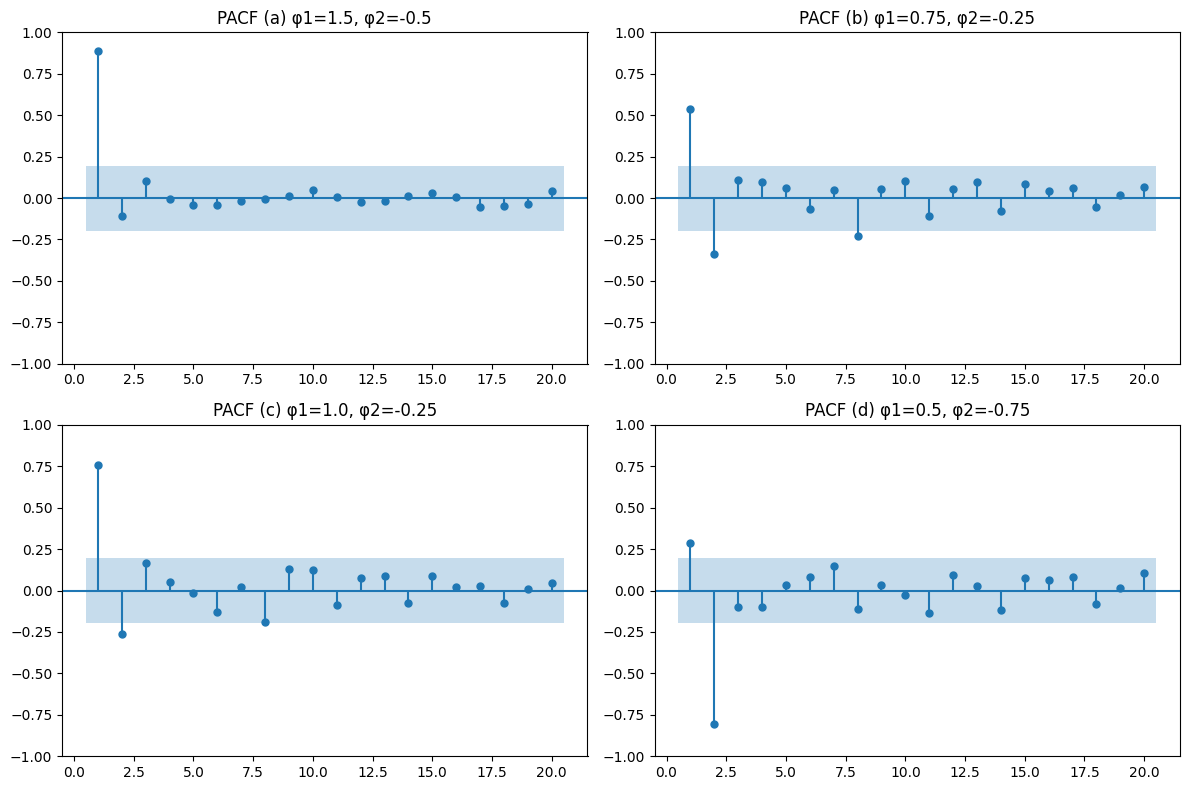

In [ ]:
# Nomor 11 (lanjutan)
# Plot PACF dari masing-masing deret hasil simulasi pada nomor 10

for start in range(0, len(label_ar2), 4):
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    axes = axes.flatten()

    subset_label = label_ar2[start:start+4]

    for i, label in enumerate(subset_label):
        phi1, phi2 = kasus_ar2[label]
        plot_pacf(hasil_ar2[label], zero=False, lags=20, ax=axes[i])
        axes[i].set_title(f'PACF ({label}) φ1={phi1}, φ2={phi2}')

    for j in range(len(subset_label), 4):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

**Jawaban / interpretasi nomor 11:**

- **Kasus (a)** $\phi_1=1.5,\phi_2=-0.5$ (non-stasioner/akar unit): ACF **meluruh sangat lambat**
  (mendekati garis lurus, tidak turun cepat ke nol) — ciri khas deret tidak stasioner, mirip dengan
  langkah acak. Bentuk ACF yang tidak meluruh inilah sinyal utama ketidakstasioneran, bukan sekadar
  "AR(2) biasa".
- **Kasus (b) dan (d)** ($\phi_1=0.75,\phi_2=-0.25$ dan $\phi_1=0.5,\phi_2=-0.75$, akar karakteristik
  kompleks karena $\phi_1^2+4\phi_2<0$): ACF meluruh membentuk **gelombang teredam (damped sinusoid)**
  — tanda $\rho_k$ berganti secara periodik seiring lag bertambah, mencerminkan pola siklis/pseudo-
  periodik dalam deret. Pada kasus (d), $|\phi_2|=0.75$ lebih besar sehingga modulus akar
  ($\sqrt{|\phi_2|}\approx0.866$) lebih mendekati 1 → osilasi meluruh **lebih lambat** dan lebih
  tampak dibanding kasus (b) ($\sqrt{0.25}=0.5$, osilasi meluruh lebih cepat).
- **Kasus (c)** $\phi_1=1,\phi_2=-0.25$ ($\phi_1^2+4\phi_2=0$, akar real kembar): ACF meluruh secara
  **eksponensial tanpa osilasi** (mirip AR(1) dengan peluruhan campuran), karena tidak ada komponen
  imajiner pada akar karakteristiknya.
- Pada **seluruh kasus stasioner (b, c, d)**, **PACF terpotong (cut-off) tegas setelah lag 2** — hanya
  lag 1 dan lag 2 yang signifikan secara statistik, konsisten dengan teori PACF$(k)=0$ untuk $k>2$
  pada proses AR(2) — ini adalah dasar penentuan ordo $p=2$.

## Soal 12
Berdasarkan plot ACF dan PACF pada nomor 11, model apa yang disarankan untuk masing-masing deret?
Jelaskan jawaban Anda.

**Jawaban:**

- **Kasus (b) $\phi_1=0.75,\phi_2=-0.25$**, **(c) $\phi_1=1,\phi_2=-0.25$**, dan
  **(d) $\phi_1=0.5,\phi_2=-0.75$**: model yang disarankan adalah **AR(2)**, karena ACF meluruh
  secara gradual (baik monoton maupun berosilasi/gelombang teredam — bukan cut-off tajam), sementara
  PACF terpotong tegas tepat setelah **lag 2** (dua lag pertama signifikan, lag $\ge3$ tidak). Ordo
  PACF yang signifikan menunjukkan ordo AR $p=2$, sesuai proses pembangkitannya.
- **Kasus (a) $\phi_1=1.5,\phi_2=-0.5$**: sebelum memodelkan sebagai AR, perlu diperhatikan bahwa
  deret ini **tidak memenuhi syarat kestasioneran** ($\phi_1+\phi_2=1$, tepat di batas), dan pola
  ACF-nya yang meluruh sangat lambat (near unit-root) menjadi indikasi kuat ketidakstasioneran.
  Model **AR(2) langsung tidak disarankan** untuk data seperti ini; yang disarankan adalah
  **melakukan pembedaan (differencing)** terlebih dahulu (menuju model ARIMA, dibahas pada
  pertemuan berikutnya) sebelum mengidentifikasi ordo AR/MA dari deret yang sudah stasioner.
- Kesimpulan umum: penentuan ordo AR(p) dilakukan dengan melihat **lag terakhir PACF yang masih
  signifikan**, sedangkan **bentuk peluruhan ACF (monoton vs berosilasi)** memberi informasi
  tambahan mengenai sifat akar karakteristik (real vs kompleks) dari proses AR tersebut. Namun
  langkah ini hanya valid **jika deret sudah stasioner** — jika tidak, ACF yang meluruh sangat
  lambat harus lebih dulu ditangani melalui differencing.